In [63]:
import os
from pathlib import Path
import pandas as pd
from nba_api.stats.endpoints import commonallplayers
from collections import defaultdict
from datetime import datetime
from nba_api.stats.endpoints import playercareerstats
from collections import Counter
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

In [2]:
# Setting the working directory to the location of the notebook
notebook_filename = "add_nba_career_data.ipynb"
notebook_path = Path(notebook_filename).resolve()
notebook_dir = notebook_path.parent
os.chdir(notebook_dir)
f = './inputs/nba-pre-draft-numbers.xlsx'

# Data Ingest

## Read Main File

In [3]:
def rename_duplicate_columns(columns, suffix='/g'):
    counts = Counter()
    new_columns = []
    for col in columns:
        counts[col] += 1
        if counts[col] == 1:
            new_columns.append(col)
        else:
            new_columns.append(f"{col}{suffix * (counts[col] - 1)}")
    return new_columns

In [131]:
# loop through all sheets in the excel file and store them in a dictionary
sheets = pd.read_excel(f, sheet_name=None)
# Create a new dictionary to hold the cleaned data
df_dict = {}
# Loop through each sheet and clean the data
for sheet_name, df in sheets.items():
    df = pd.read_excel(f, sheet_name=sheet_name, header=1, dtype=str)

    # Some preprocessing to clean the data
    player_name_col = 'Player' if 'Player' in df.columns else 'PLAYER'
    df.dropna(subset=[player_name_col], inplace=True)

    # replace colnames that have .1 with /g
    df.columns = df.columns.str.replace('.1', '/g', regex=False)

    if sheet_name == 'First Round':
        columns_to_clean = [col for col in df.columns if 'Percentile' in col or '%' in col]
        for col in columns_to_clean:
            # Remove '%' if present, and convert to float
            df[col] = df[col].astype(str).str.replace('%', '')
        # replace 'x' in all columns with empty
        df.replace(to_replace='^x$', value='', regex=True, inplace=True)

    # # if no spaces in in player name field, add spaces between lowercase and uppercase letters
    # # Only add a space for the first instance of lowercase followed by uppercase in each name
    # df[player_name_col] = df[player_name_col].apply(
    #     lambda x: x if pd.isna(x) else pd.Series(x).str.replace(r'([a-z])([A-Z])', r'\1 \2', regex=True, n=1).iloc[0]
    # )

    # Store the cleaned DataFrame in the dictionary
    df_dict[sheet_name] = df

## Get Player NBA Career Numbers

In [5]:
all_players = commonallplayers.CommonAllPlayers(is_only_current_season=0).get_data_frames()[0]
player_names = all_players['DISPLAY_FIRST_LAST'].tolist()
player_ids = all_players['PERSON_ID'].tolist() # use player IDs to match with the pre-draft data

In [6]:
# function to get player ID by name, with fuzzy matching option
def get_player_id(name, fuzzy=True):
    """
    Get the player ID for a given player name.
    If fuzzy is True, it will use fuzzy matching to find the closest match.
    """

    global player_names, player_ids
    from rapidfuzz import process
    from rapidfuzz.fuzz import token_sort_ratio

    if fuzzy:
        matches = process.extract(name, player_names, limit=5, scorer=token_sort_ratio)
        if not matches:
            print(f"No matches found for {name}.")
            return None
        # Find the best match above a threshold
        best_match, score, index = matches[0]
        if score > 80:  # threshold
            matched_player_id= player_ids[index]
            return matched_player_id
        else:
            # print(f"No close match found for {name}.")
            return None
    
    index, match = next(((i, player) for i, player in enumerate(player_names) if player == name), (None,None))
    if index is None:
        # print(f"No exact match found for {name}.")
        return None
    return player_ids[index]

# test the function with a sample name
get_player_id('Victor Wembanyama', fuzzy=True)  # Example usage with fuzzy matching

1641705

In [132]:
# add player IDs to each DataFrame

missing_players = defaultdict(list)  # To store missing player names
for sheet_name, df in df_dict.items():
    # Current year sheets are not processed for NBA career data
    if sheet_name == datetime.now().strftime('%Y'):
        continue
    player_name_col = 'Player' if 'Player' in df.columns else 'PLAYER'
    for i, row in df.iterrows():
        # Find the player ID using the player's name
        player_name = row[player_name_col]
        player_id = get_player_id(player_name, fuzzy=False)
        if player_id is None:
            player_id = get_player_id(player_name, fuzzy=True)
        
        if player_id is None:
            missing_players[sheet_name].append(player_name)
            player_id = -1  # Assign a default value for missing players
            # continue
        
        df.at[i, 'Player ID'] = player_id
    df['Player ID'] = df['Player ID'].astype(int)

    # Store the updated DataFrame back in the dictionary
    df_dict[sheet_name] = df

## Get Career Stats data if needed

In [101]:
sheet_names = [sheet_name.lower() for sheet_name, df in df_dict.items()]
for sheet_name, df in df_dict.items():
    # Skip the current year sheet or sheets already containings nba career stats
    if (sheet_name == datetime.now().strftime('%Y')) | ('stats' in sheet_name.lower()) | (sheet_name in ['First Round','Ainge Picks']):
        continue

    # Skip if year already has NBA career stats
    if sheet_name + ' stats' in sheet_names:
        print(f"Skipping {sheet_name} as it already has NBA career stats.")
        continue

    print(f"Processing {sheet_name}...")


    career_df_list = []
    for i, row in df.iterrows():
        player_id = row['Player ID']
        if (pd.isna(player_id)) | (player_id == -1):
            continue  # Skip if Player ID is NaN
        
        # Fetch career statistics for the player
        try:
            career_stats = playercareerstats.PlayerCareerStats(player_id=player_id, per_mode36='Totals')
            stats_df = career_stats.get_data_frames()[0]
            if stats_df.empty:
                print(f"No career stats found for {row['PLAYER']}, player ID {player_id}.")
                continue
        except Exception as e:
            print(f"Error fetching stats for player ID {player_id}: {e}")
            continue

        # Check if the player's career started before the sheet year - indicates that the incorrect player ID was used
        if int(stats_df.loc[0,'SEASON_ID'][:4]) < int(sheet_name):
            print(f"Skipping {row['PLAYER']} (ID: {player_id}) as their career started before {sheet_name}. Please check the player id")
            continue

        # calculate career totals
        tot_vars = ['GP', 'MIN','PTS','REB','AST']
        tot_varnames = ['G','MP','PTS','TRB','AST']
        vals = []
        for var in tot_vars:
            val = stats_df[var].sum()
            vals.append(val)

        # calculate career averages for shooting
        fgp = (stats_df['FGM'].sum() / stats_df['FGA'].sum()) * 100 if stats_df['FGA'].sum() > 0 else 0
        fgp3 = (stats_df['FG3M'].sum() / stats_df['FG3A'].sum()) * 100 if stats_df['FG3A'].sum() > 0 else 0
        ftp = (stats_df['FTM'].sum() / stats_df['FTA'].sum()) * 100 if stats_df['FTA'].sum() > 0 else 0
        shooting_varnames = ['FG%', '3P%', 'FT%']
        vals.extend([fgp, fgp3, ftp])

        # calculate career per game averages
        per_game_vars = ['MIN','PTS','REB','AST']
        # agg_ave_vars = ['REB','OREB','DREB','AST','STL','BLK','TOV','PTS']
        per_game_varnames = ['MP','PTS','TRB','AST']
        for var in per_game_vars:
            val = stats_df[var].sum() / stats_df['GP'].sum()
            vals.append(val)

        cols = tot_varnames + shooting_varnames + per_game_varnames
        tmp_df = pd.DataFrame([vals], columns=cols)
        career_df_list.append(tmp_df)

    df_dict[sheet_name + ' stats'] = pd.concat(career_df_list, ignore_index=True)

Skipping 2024 as it already has NBA career stats.
Skipping 2023 as it already has NBA career stats.
Skipping 2022 as it already has NBA career stats.
Skipping 2021 as it already has NBA career stats.
Skipping 2020 as it already has NBA career stats.
Skipping 2019 as it already has NBA career stats.


# Analysis

In [8]:
# concatenate all the career stats DataFrames into one
career_df_names = [name for name in df_dict.keys() if 'stats' in name.lower()]
career_df = pd.concat([df_dict[name] for name in career_df_names], ignore_index=True)
main_df = df_dict['First Round'].copy()

In [9]:
all_df = pd.merge(main_df, career_df, how='inner', left_on='PLAYER', right_on='Player', suffixes=('_draft', '_career'))
x_col = 'Jumper off the Dribble Percentile'
y_cols = ['MP/g','PTS/g','TRB/g','AST/g','FG%','3P%','WS/48','BPM','VORP_career']
all_df = all_df.dropna(subset=[x_col])
# x = df[x_col]
all_df = all_df[all_df[x_col] != 'x']
# ys = all_df[y_cols]

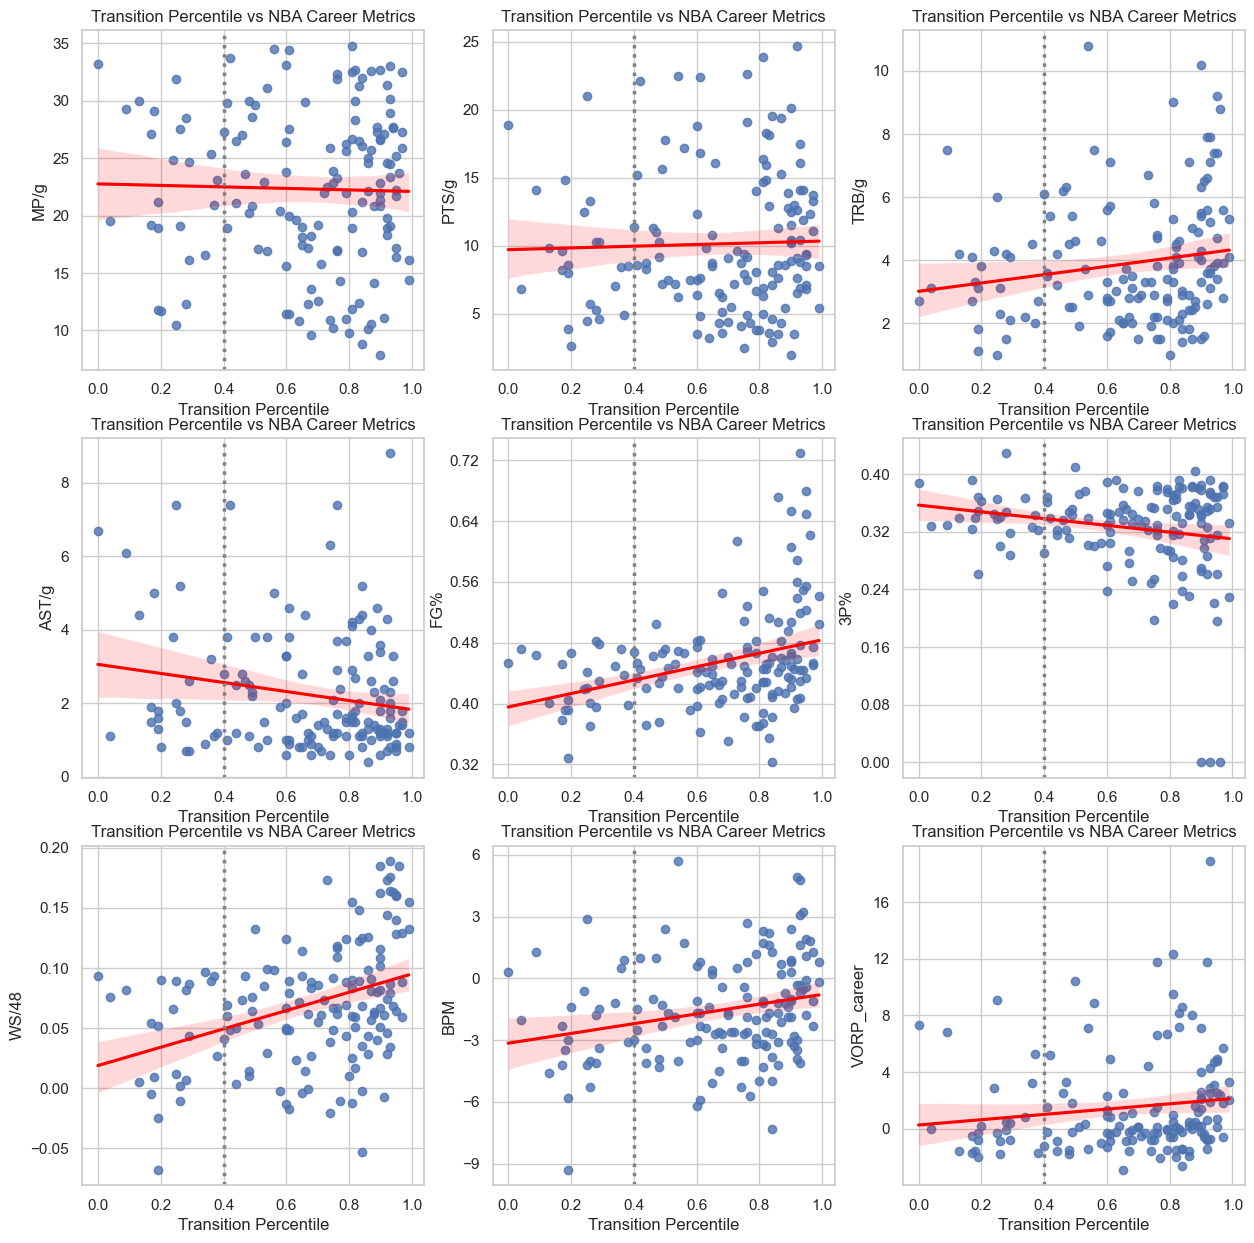

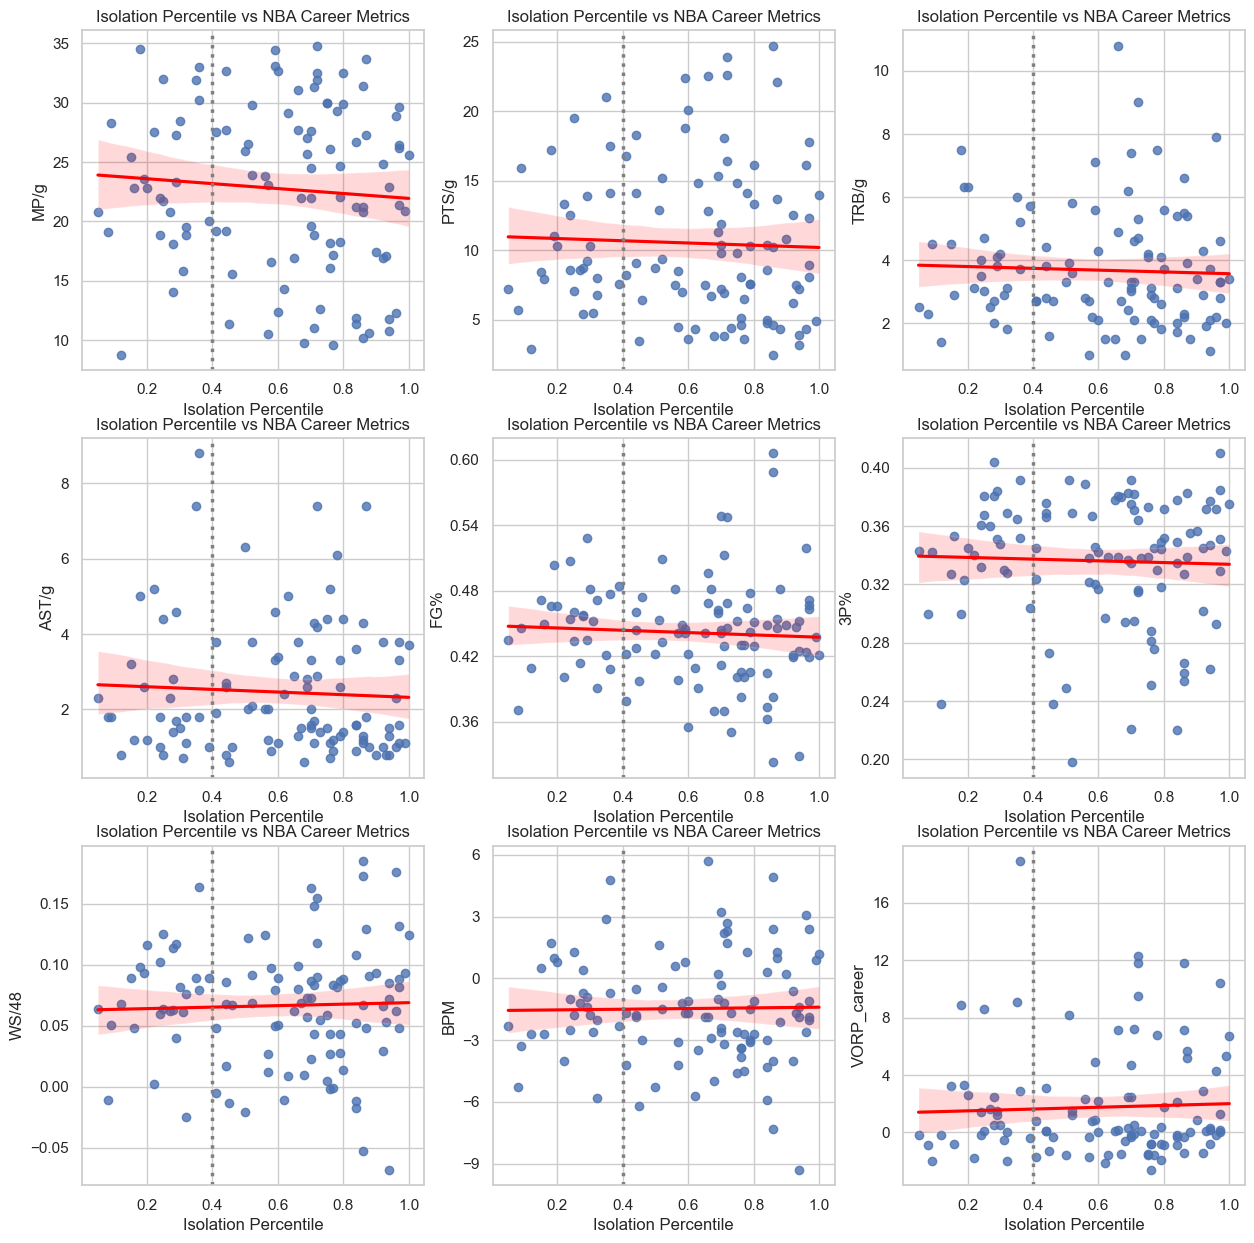

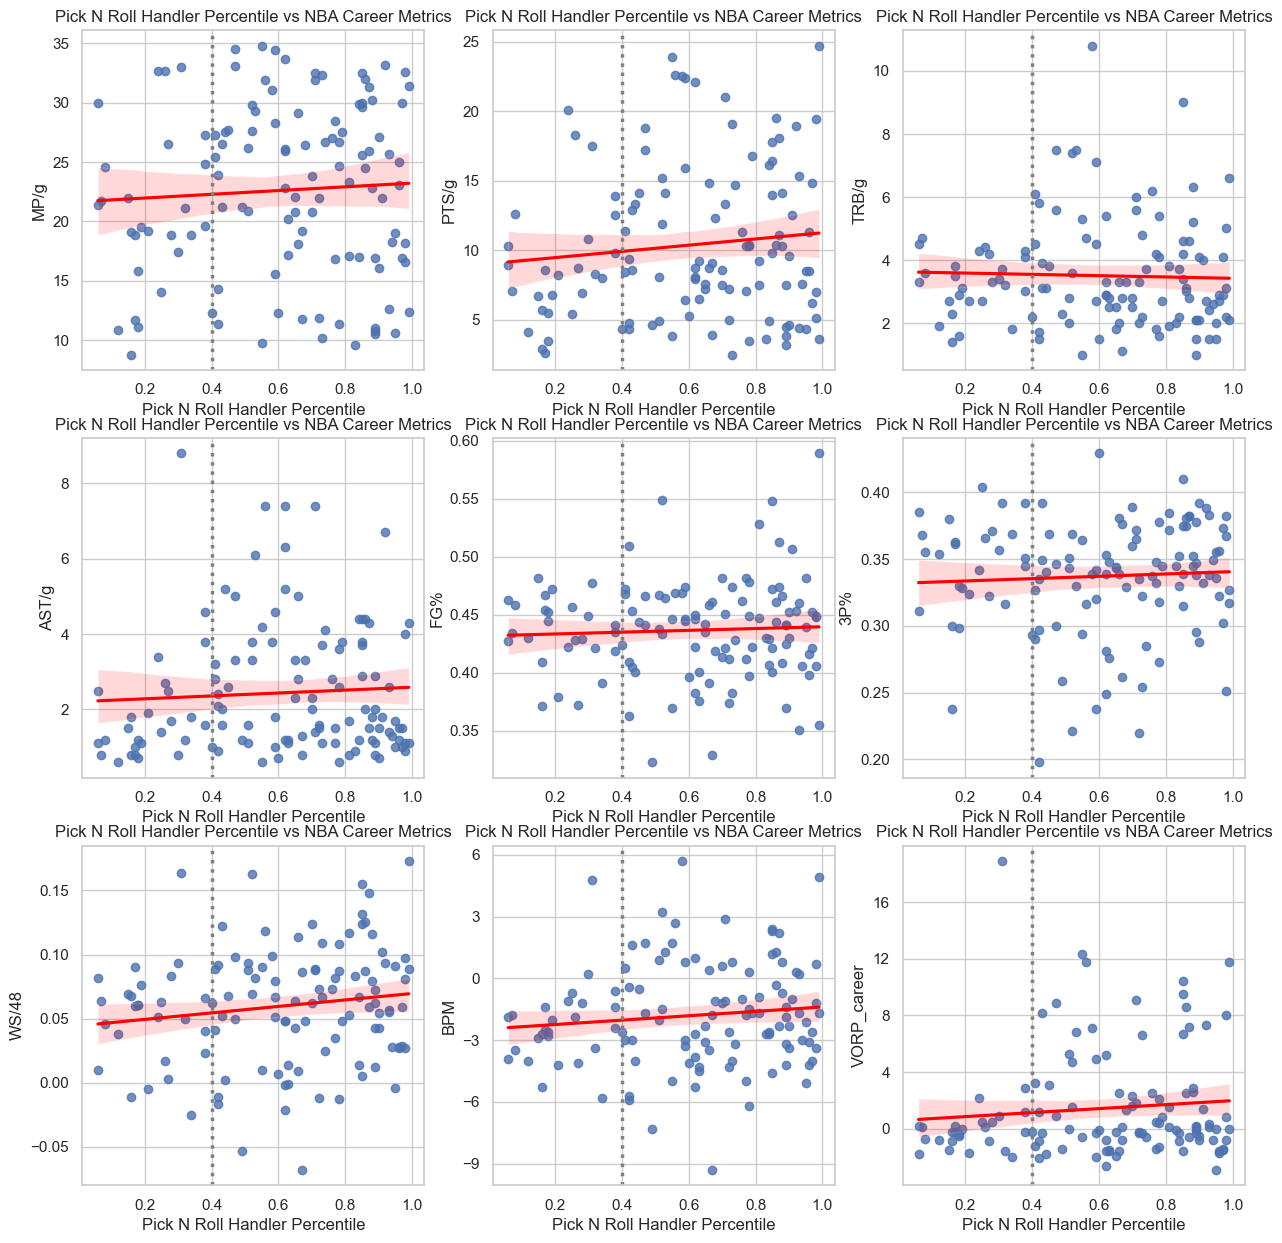

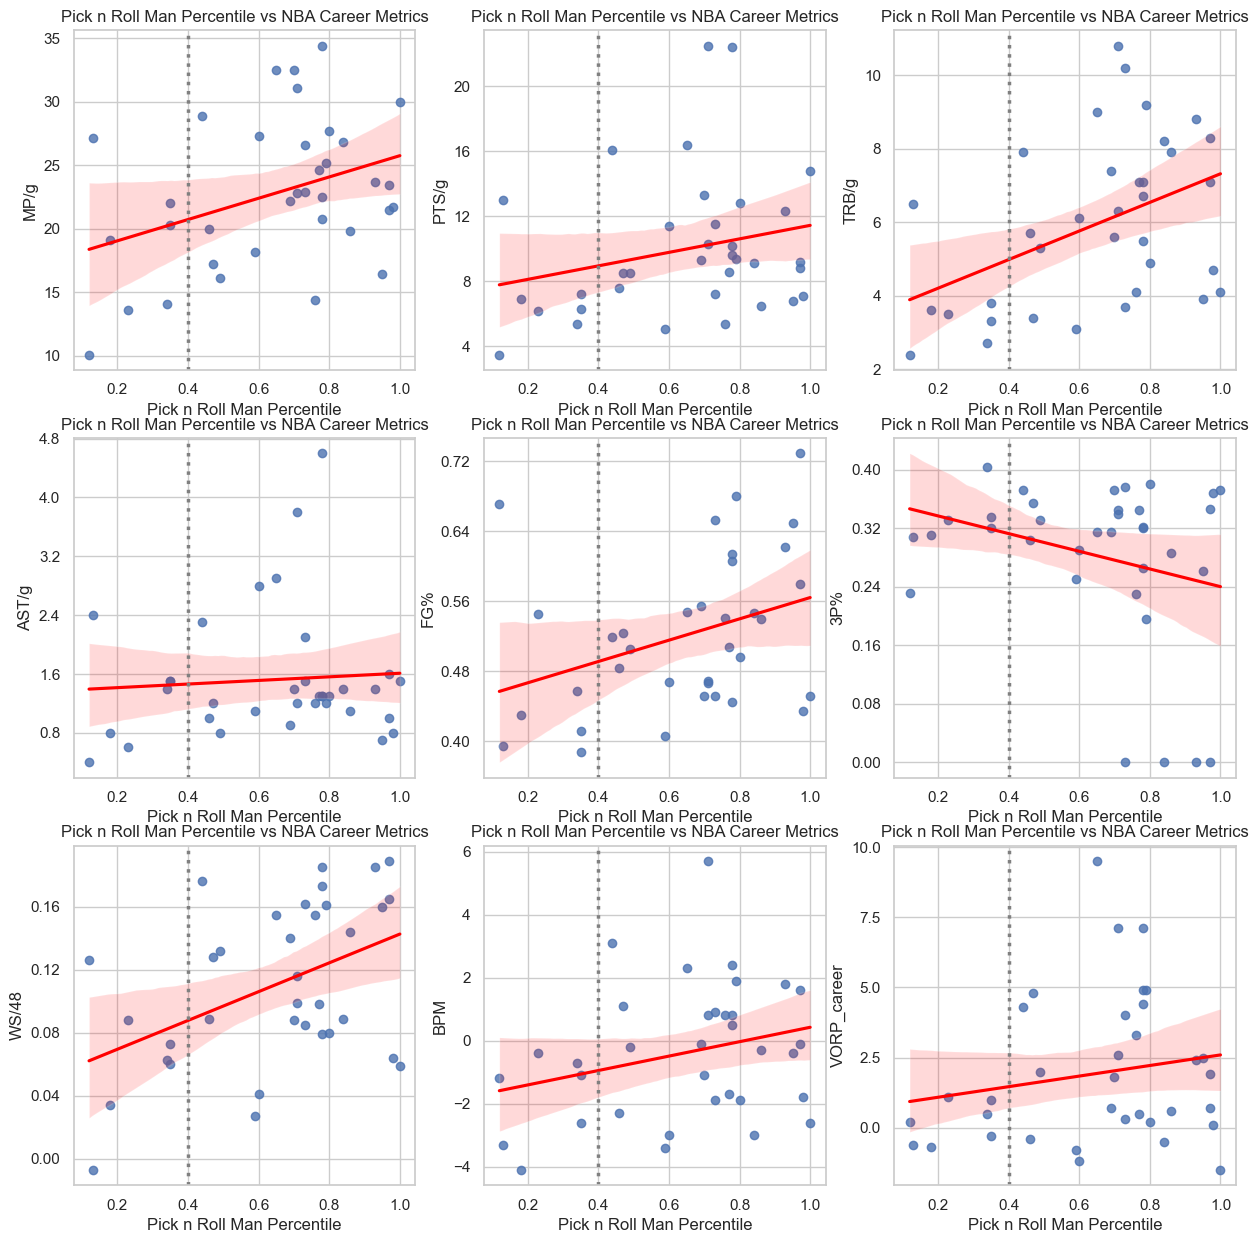

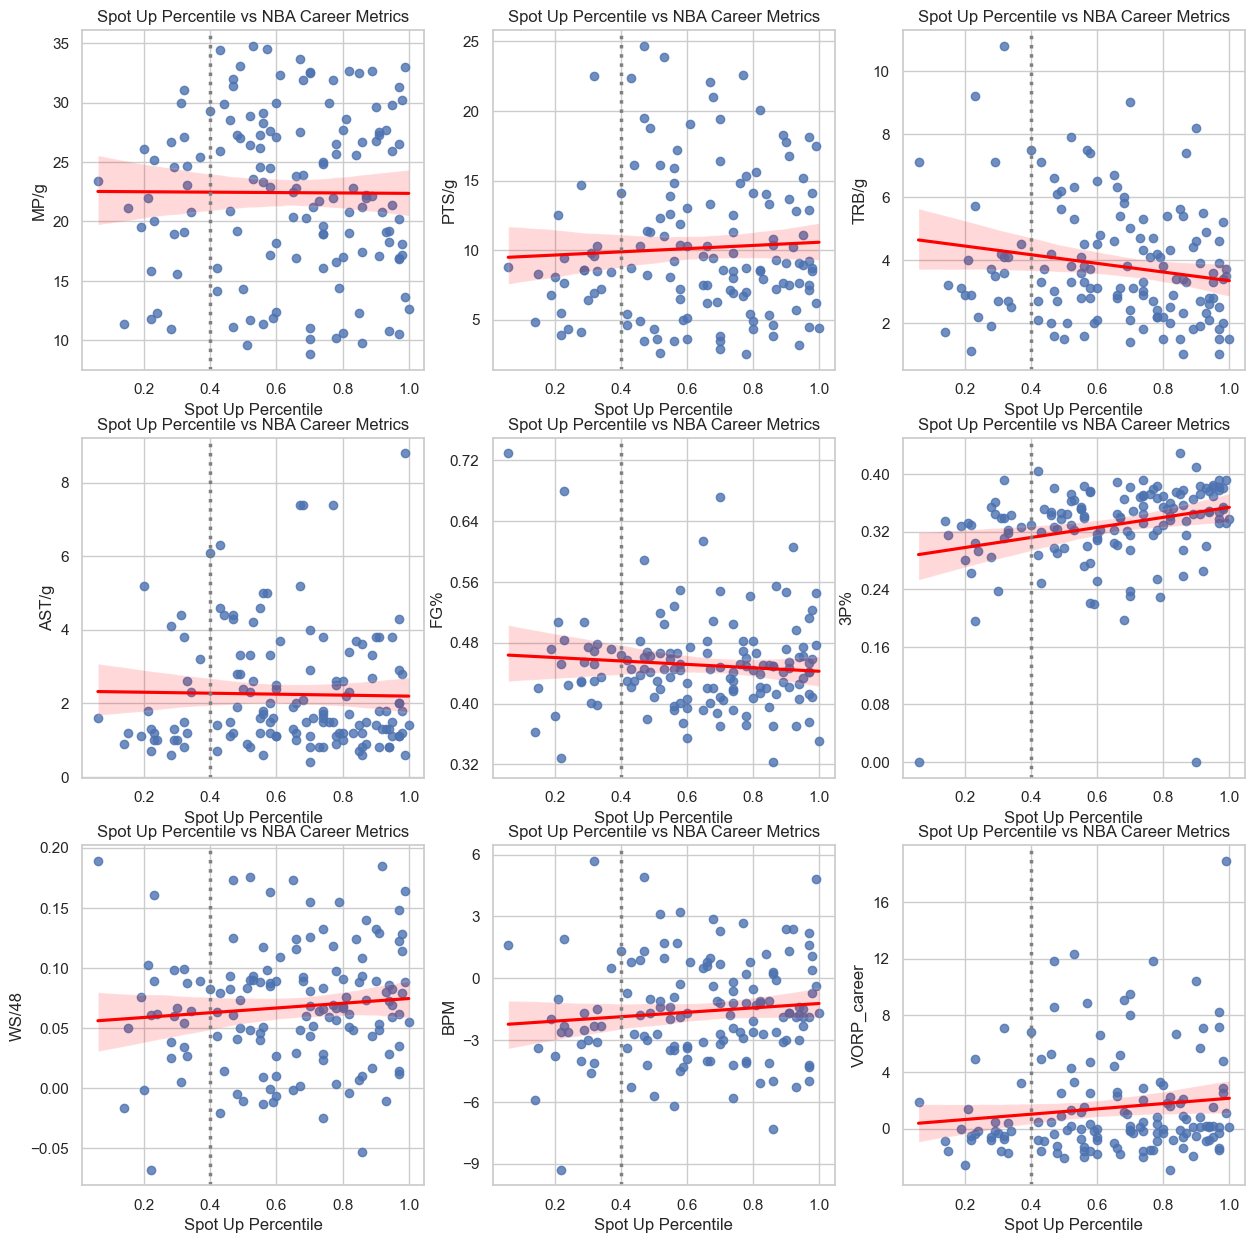

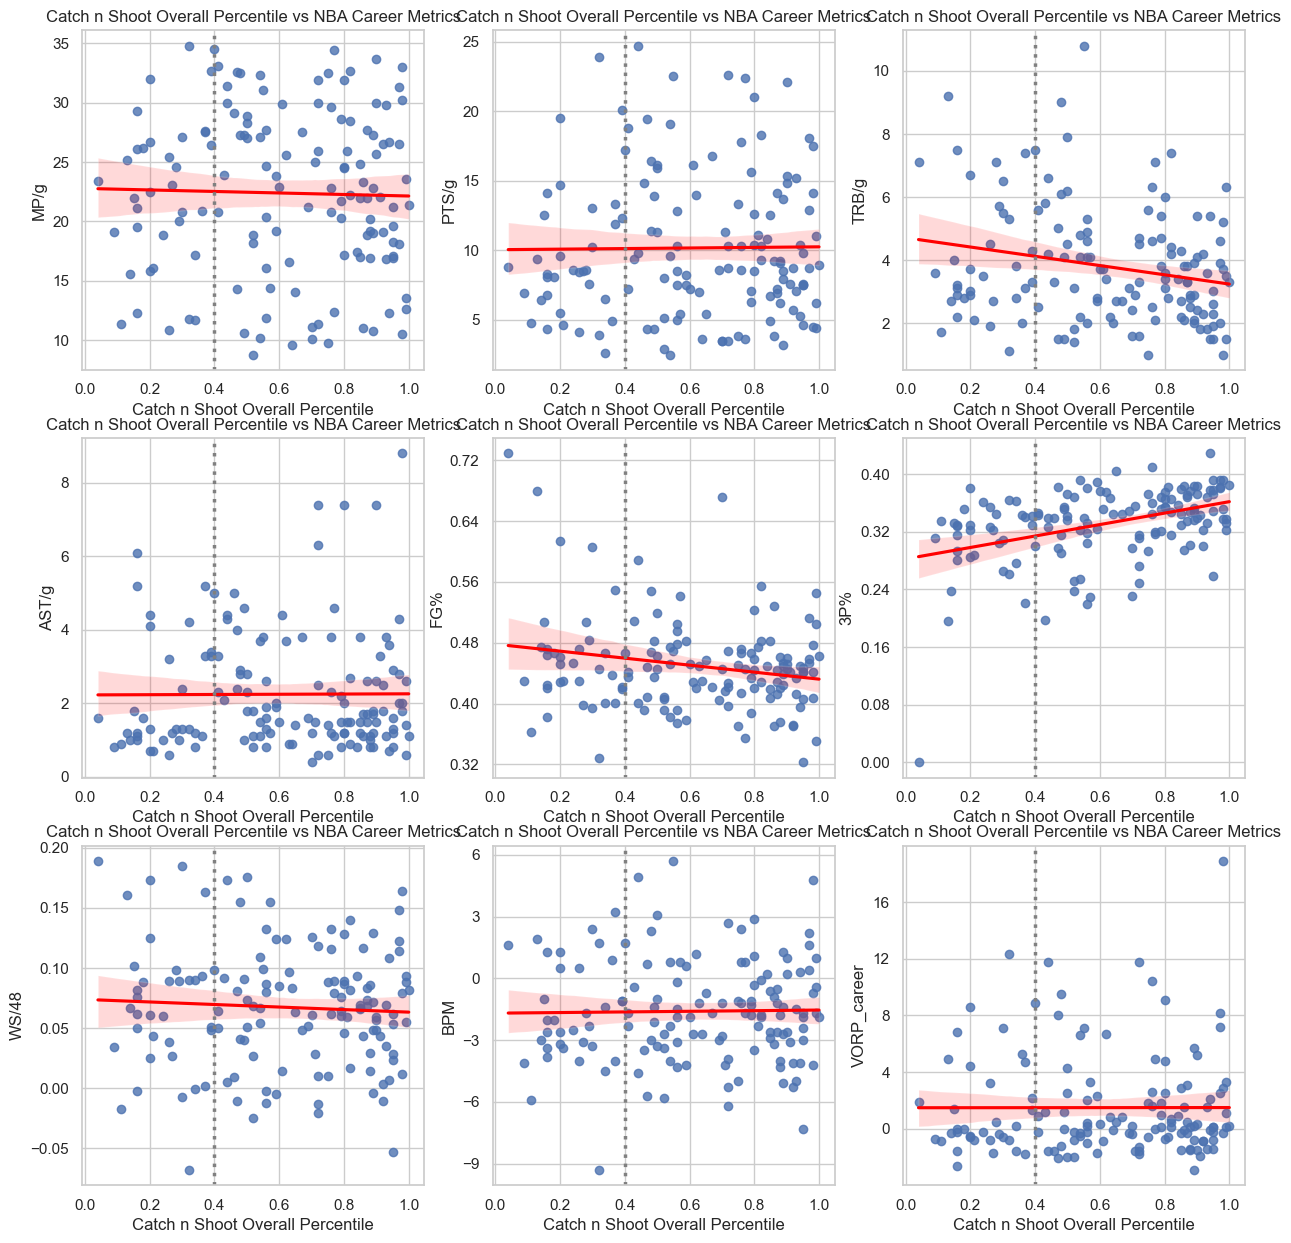

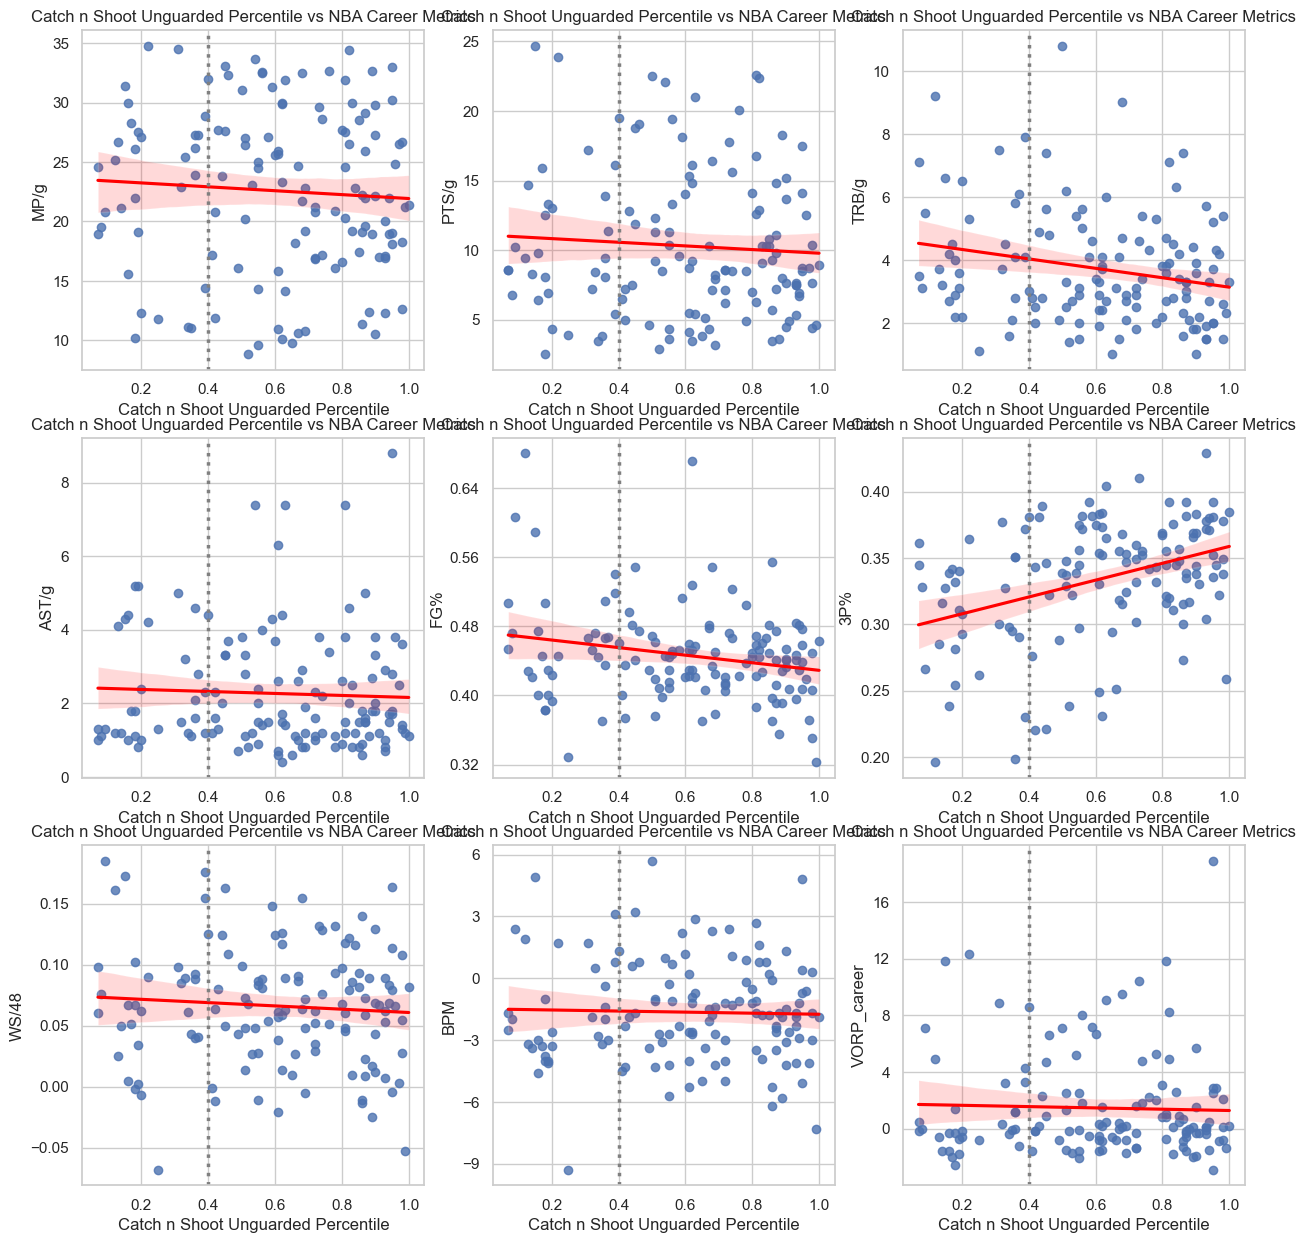

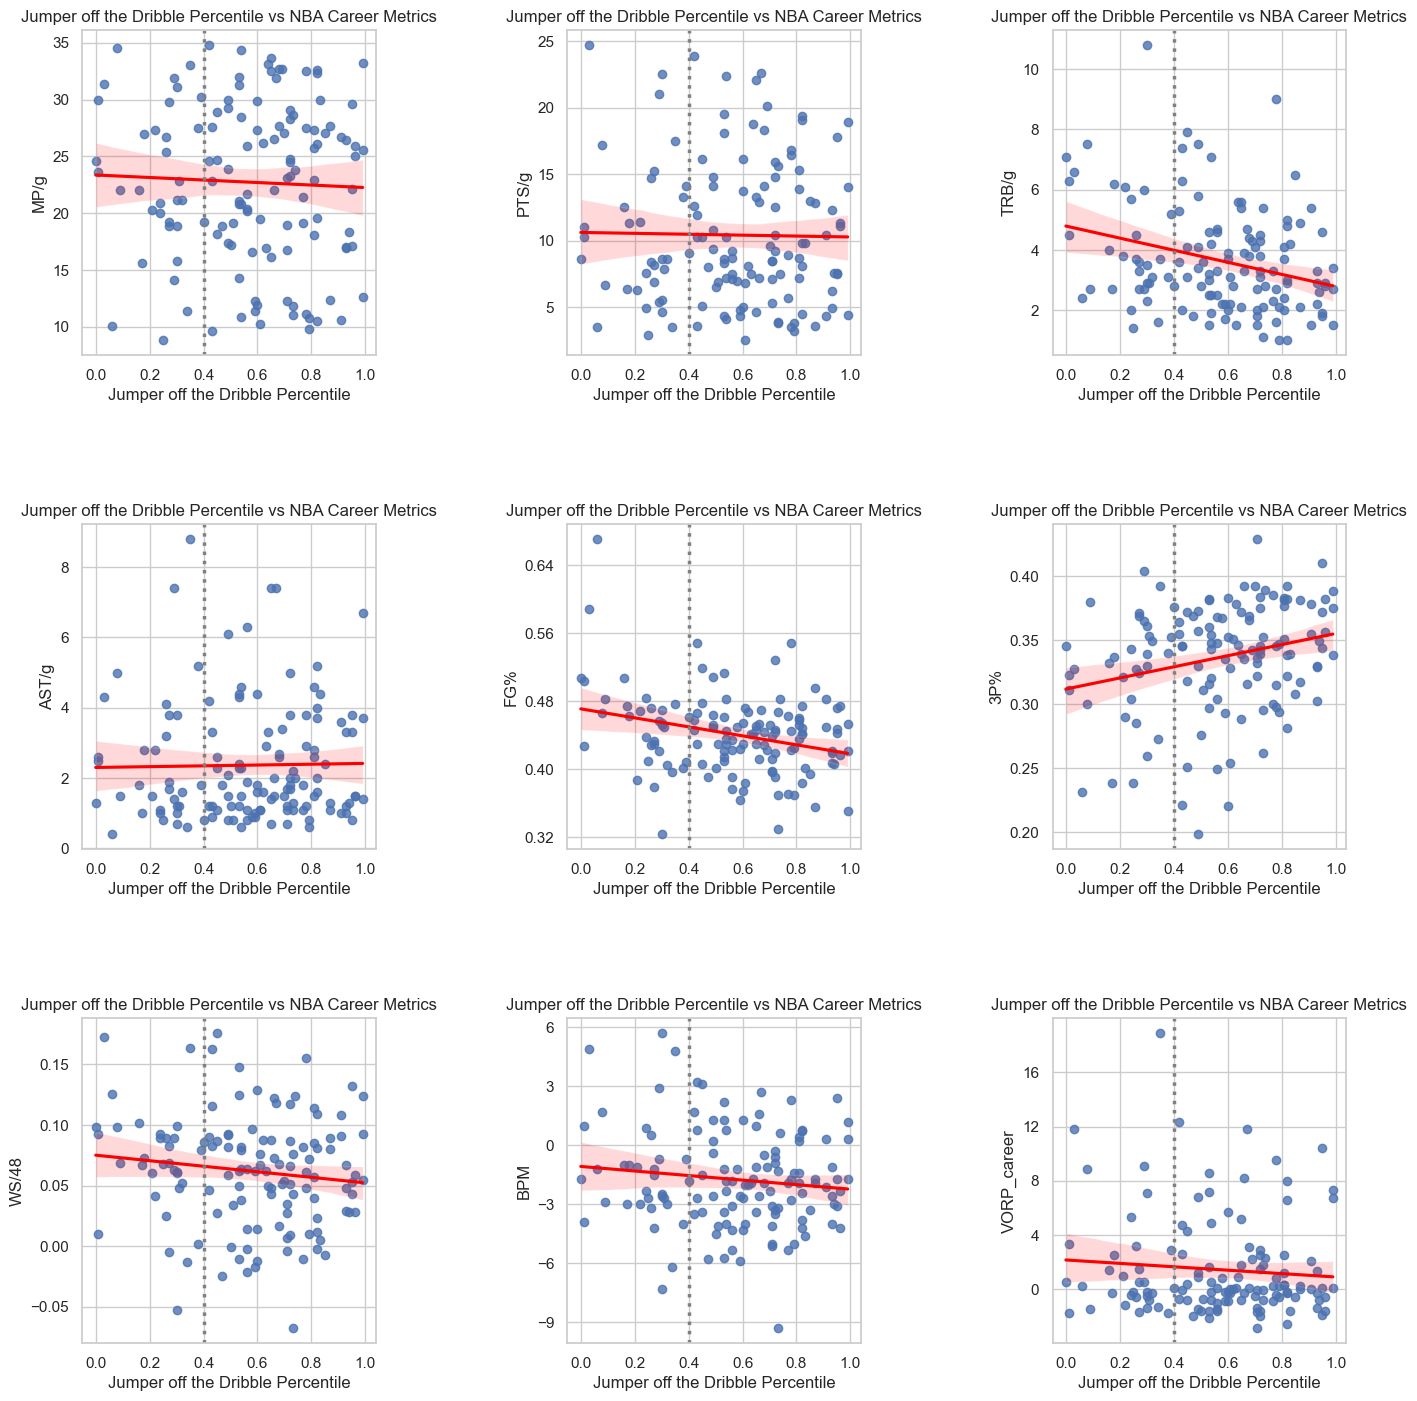

In [80]:
all_df = pd.merge(main_df, career_df, how='inner', left_on='PLAYER', right_on='Player', suffixes=('_draft', '_career'))
x_cols = ['Transition Percentile','Isolation Percentile','Pick N Roll Handler Percentile','Pick n Roll Man Percentile','Spot Up Percentile','Catch n Shoot Overall Percentile','Catch n Shoot Unguarded Percentile','Jumper off the Dribble Percentile']

for x_col in x_cols:
    sns.set(style="whitegrid")
    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 15))

    for ax, y_col in zip(axes.flatten(), y_cols):
        if x_col in all_df.columns and y_col in all_df.columns:
            tmp_df = all_df.dropna(subset=[x_col]).copy()
            tmp_df = tmp_df[tmp_df[x_col] != 'x']
            subset_df = tmp_df[[x_col, y_col]].dropna(subset=[x_col, y_col])
            subset_df[x_col] = pd.to_numeric(subset_df[x_col], errors='coerce')
            subset_df[y_col] = pd.to_numeric(subset_df[y_col], errors='coerce')
            
            if not subset_df.empty:
                # Use regplot instead of scatterplot to add a trendline
                sns.regplot(data=subset_df, x=x_col, y=y_col, ax=ax, scatter=True, line_kws={"color":"red"})
                ax.set_title(f'{y_col} vs {x_col}')
                ax.set_xlabel(x_col)
                ax.set_ylabel(y_col)
                ax.grid(True)
                ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
            else:
                ax.set_title(f'No data for {y_col} vs {x_col}')
                ax.axis('off')
            
            ax.axvline(x=0.4, color='gray', linestyle='dotted', linewidth=2.5)
            ax.set_title(f'{x_col} vs NBA Career Metrics')
        else:
            ax.set_title(f'Missing data for {y_col} or {x_col}')
            ax.axis('off')

    fig.savefig(f'./outputs/{x_col}_vs_career_stats.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()


In [11]:
def get_correlation_df(df, x_cols=[], y_cols=[]):
    """
    Calculate the correlation between specified x_cols and y_cols in a DataFrame.
    
    Parameters:
    df (pd.DataFrame): The DataFrame containing the data.
    x_cols (list): List of column names to use as x variables.
    y_cols (list): List of column names to use as y variables.
    
    Returns:
    pd.DataFrame: A DataFrame containing the correlation coefficients and p-values.
    """

    if not x_cols:
        x_cols = ['Transition Percentile','Isolation Percentile','Isolation Score %','Pick N Roll Handler Percentile','Pick n Roll Man Percentile','Spot Up Percentile','Catch n Shoot Overall Percentile','Catch n Shoot Unguarded Percentile','Jumper off the Dribble Percentile']
    if not y_cols:
        y_cols = ['MP/g','PTS/g','TRB/g','AST/g','FG%','3P%','WS/48','BPM','VORP_career']

    # Clean column names to ensure consistency (optional)
    df.columns = df.columns.str.strip()

    # Calculate correlation for each x_col vs each y_col
    corr_arrs = []
    p_arrs = []
    for x in x_cols:
        corr_arr = []
        p_arr = []
        for y in y_cols:
            tmp_df = df[[x, y]].dropna(subset=[x, y])
            # tmp_df[x] = [float(val) if isinstance(val, (int, float)) or str(val).replace('.', '', 1).isdigit() else np.nan for val in tmp_df[x]]
            tmp_df = tmp_df[tmp_df[x] != 'nan']  # Remove rows where x is 'x'
            tmp_df[x] = pd.to_numeric(tmp_df[x], errors='coerce')
            tmp_df[y] = pd.to_numeric(tmp_df[y], errors='coerce')
            tmp_df = tmp_df[[x, y]].dropna(subset=[x, y])
            # tmp_df = tmp_df.astype({x: 'float', y: 'float'})
            # Only compute if there are at least 2 valid rows
            if tmp_df[x].notna().sum() > 1 and tmp_df[y].notna().sum() > 1:
                corr, pval = pearsonr(tmp_df[x], tmp_df[y])
            else:
                corr, pval = float('nan'), float('nan')
            corr_arr.append(corr)
            p_arr.append(pval)
        corr_arrs.append(corr_arr)
        p_arrs.append(p_arr)

    corr_df = pd.DataFrame(corr_arrs, index=x_cols, columns=y_cols)
    pval_df = pd.DataFrame(p_arrs, index=x_cols, columns=y_cols)

    return corr_df, pval_df

In [77]:

def plot_corr_heatmap(corr_df, pval_df):
    """
    Plot a heatmap of the correlation coefficients with significance boxes.
    
    Parameters:
    corr_df (pd.DataFrame): DataFrame containing correlation coefficients.
    pval_df (pd.DataFrame): DataFrame containing p-values for significance.
    x_cols (list): List of x variable names.
    y_cols (list): List of y variable names.
    """

    # Set up the figure and axis
    plt.figure(figsize=(12, 8))
    sns.set(style="whitegrid")

    ax = sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", center=0,
                    linewidths=.5, cbar_kws={"label": "Correlation"})

    plt.title("Pre-Draft v NBA Career Metrics Correlation", fontdict={'fontsize': 16, 'fontweight': 'bold'})
    plt.xlabel("NBA Career Metrics", fontdict={'fontsize': 14})
    plt.ylabel("Pre-Draft Metrics", fontdict={'fontsize': 14})

    # Draw boxes and hatching
    for i in range(len(corr_df.index)):
        for j in range(len(corr_df.columns)):
            pval = pval_df.iloc[i, j]
            if pval < 0.1:
                ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='black', lw=0.1))
            if pval < 0.05:
                ax.add_patch(mpatches.Rectangle((j, i), 1, 1, facecolor='none', hatch='//', edgecolor='black'))

    # Legend proxies
    box_proxy = mpatches.Patch(facecolor='none', edgecolor='black', linewidth=2, label='p < 0.1')
    hatch_proxy = mpatches.Patch(facecolor='white', hatch='//', edgecolor='black', label='p < 0.05')

    plt.legend(handles=[box_proxy, hatch_proxy], loc='upper left', bbox_to_anchor=(-0.4, 1), title="Significance")

    plt.show()

    return ax.figure



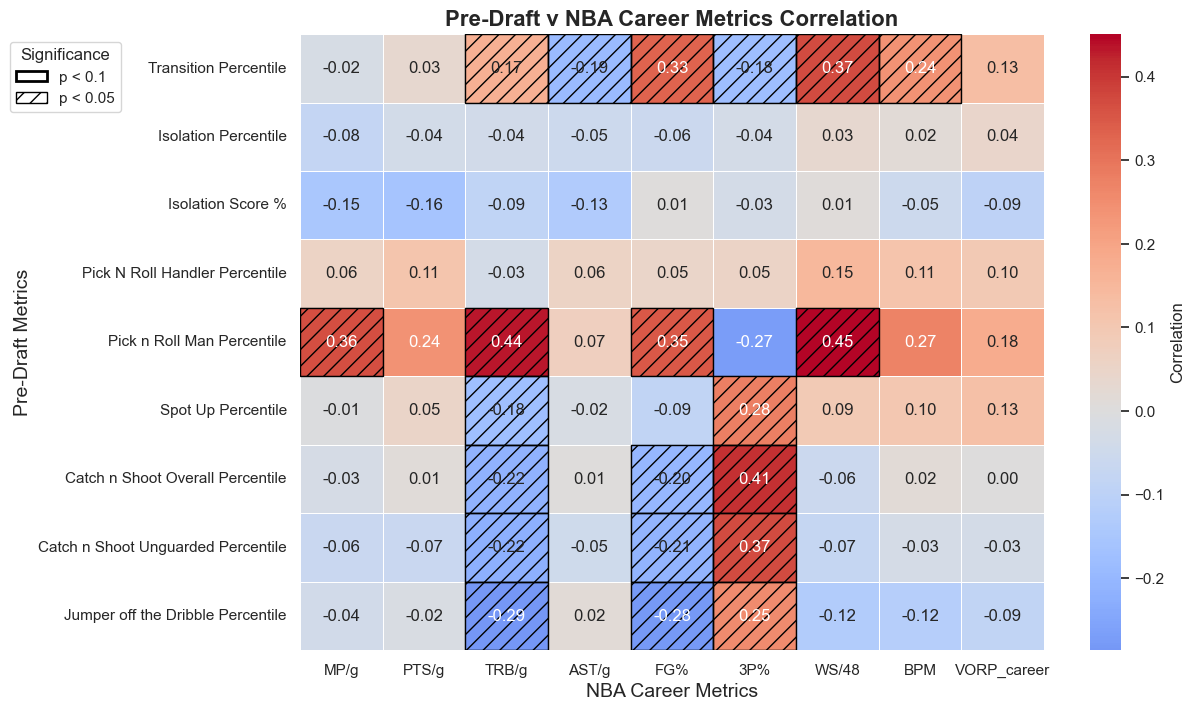

In [78]:
main_df = df_dict['First Round'].copy()
main_df.columns = main_df.columns.str.strip()  # Clean column names to ensure consistency
# main_df = main_df[main_df['first'] == '2019']
all_df = pd.merge(main_df, career_df, how='inner', left_on='PLAYER', right_on='Player', suffixes=('_draft', '_career'))
corr_df, pval_df = get_correlation_df(all_df)
fig = plot_corr_heatmap(corr_df, pval_df)
fig.savefig('./outputs/correlation_heatmap.png', dpi=300, bbox_inches='tight')

In [97]:
test = tmp_df[tmp_df[y] >= 0.35]

In [100]:
tmp_df = all_df.dropna(subset=[x, y])
# tmp_df[x] = [float(val) if isinstance(val, (int, float)) or str(val).replace('.', '', 1).isdigit() else np.nan for val in tmp_df[x]]
tmp_df = tmp_df[tmp_df[x] != 'nan']  # Remove rows where x is 'x'
tmp_df[x] = pd.to_numeric(tmp_df[x], errors='coerce')
tmp_df[y] = pd.to_numeric(tmp_df[y], errors='coerce')
tmp_df = tmp_df.dropna(subset=[x, y])

In [103]:
test = tmp_df[tmp_df[y] >= 0.35][['PLAYER',x,y]]

In [95]:
pre_draft_shooting_cols = ['Spot Up Percentile','Catch n Shoot Overall Percentile','Catch n Shoot Unguarded Percentile','Jumper off the Dribble Percentile']
y = '3P%'
for x in pre_draft_shooting_cols:
    y = '3P%'
    tmp_df = all_df[[x, y]].dropna(subset=[x, y])
    # tmp_df[x] = [float(val) if isinstance(val, (int, float)) or str(val).replace('.', '', 1).isdigit() else np.nan for val in tmp_df[x]]
    tmp_df = tmp_df[tmp_df[x] != 'nan']  # Remove rows where x is 'x'
    tmp_df[x] = pd.to_numeric(tmp_df[x], errors='coerce')
    tmp_df[y] = pd.to_numeric(tmp_df[y], errors='coerce')
    tmp_df = tmp_df[[x, y]].dropna(subset=[x, y])
    print(x, tmp_df[tmp_df[y] >= 0.35][x].min())
    if x == 'Catch n Shoot Overall Percentile':
        break


Spot Up Percentile 0.28
Catch n Shoot Overall Percentile 0.18


The heatmap above shows the correlation between players' Pre-Draft percentile metrics and their average NBA career stats. Correlation ranges from -1 to 1. Blue indicates negative correlation (one value goes up while the other goes down), and red indicates positive (both move in the same direction).

The bolded boxes and hashing indicate levels of statistical significance, based on the p-value from a t-test. The p-value represents the probability of observing a difference at least as extreme as the one calculated, assuming that there is no true difference (null hypothesis).

A p-value less than 0.05 suggests that the observed difference is unlikely to have occurred by random chance, and we can say there is statistically significant evidence that the two groups differ. This means we have 95% confidence that the difference is not just due to random sampling variability. Thus, you can interpret the hatched and boxed segments of the heatmap as more statistically meaningful based on the available data.

<b>Example</b>: Catch n Shoot Overall Percentile has a correlation score of 0.41 with 3P%, and is marked as statistically significant, giving confidence in the result. This points to players who are good with catch n shoot pre-draft becoming good 3-point shooters. However, the negative correlations in FG% indicate that Catch n Shoot metrics may not be predictive of overall FG% (perhaps because those tend to be the players who take more 3 pointers).Jumper off the dribble percentile could probably be interpreted similarly.

## Comparing Averages by Threshold

In [69]:
main_df = df_dict['First Round'].copy()
main_df.columns = main_df.columns.str.strip()  # Clean column names to ensure consistency
all_df = pd.merge(main_df, career_df, how='inner', left_on='PLAYER', right_on='Player', suffixes=('_draft', '_career'))

In [70]:
from scipy.stats import ttest_ind

def get_group_means_ttest_df(df, x_cols=[], y_cols=[]):
    """
    Calculate the mean of y_col for x_col < 40 and x_col >= 40 and perform t-tests.

    Parameters:
    df (pd.DataFrame): The DataFrame containing the data.
    x_cols (list): List of column names to use as x variables.
    y_cols (list): List of column names to use as y variables.

    Returns:
    pd.DataFrame: DataFrame with columns: Group1_mean (x<40), Group2_mean (x>=40), p_value
    """
    if not x_cols:
        x_cols = ['Transition Percentile','Isolation Percentile','Pick N Roll Handler Percentile','Pick n Roll Man Percentile','Spot Up Percentile','Catch n Shoot Overall Percentile','Catch n Shoot Unguarded Percentile','Jumper off the Dribble Percentile']
    if not y_cols:
        y_cols = ['MP/g','PTS/g','TRB/g','AST/g','FG%','3P%','WS/48','BPM','VORP_career']

    df.columns = df.columns.str.strip()

    # Initialize result list
    result_data = []

    for x in x_cols:
        for y in y_cols:
            if x in df.columns and y in df.columns:
                tmp_df = df[[x, y]].dropna(subset=[x, y])
                tmp_df = tmp_df[tmp_df[x] != 'nan']  # Remove rows where x is 'x'
                tmp_df[x] = pd.to_numeric(tmp_df[x], errors='coerce')
                tmp_df[y] = pd.to_numeric(tmp_df[y], errors='coerce')
                tmp_df = tmp_df[[x, y]].dropna(subset=[x, y])

                group1 = tmp_df[tmp_df[x] < 0.40][y]
                group2 = tmp_df[tmp_df[x] >= 0.40][y]

                if len(group1) >= 2 and len(group2) >= 2:
                    mean1 = group1.mean()
                    mean2 = group2.mean()
                    mean_diff_norm = (mean1 - mean2) / tmp_df[y].mean().__abs__() * 100
                    tstat, pval = ttest_ind(group1, group2, equal_var=False)
                else:
                    mean1, mean2, pval, tstat, mean_diff_norm = float('nan'), float('nan'), float('nan'), float('nan'), float('nan')

                result_data.append({'x_col': x, 'y_col': y, 'Group1_mean': mean1, 'Group2_mean': mean2, 'p_value': pval, 'tstat': tstat, 'mean_diff_norm': mean_diff_norm})

    # Convert result to DataFrame
    result_df = pd.DataFrame(result_data)
    return result_df


In [71]:
def plot_mean_diff_norm_heatmap(mean_diff_norm_df, pval_df, title="Normalized Mean Difference Heatmap"):
    """
    Plot a heatmap of normalized mean differences with significance boxes and hatching.
    
    Parameters:
    mean_diff_norm_df (pd.DataFrame): DataFrame of normalized mean differences.
    pval_df (pd.DataFrame): DataFrame of p-values for significance.
    """
    plt.figure(figsize=(12, 8))
    sns.set(style="whitegrid")

    ax = sns.heatmap(mean_diff_norm_df, annot=True, fmt=".2f", cmap="coolwarm", center=0,
                     linewidths=.5, cbar_kws={"label": "Normalized Difference (%)"}, vmin=-100, vmax=100)

    plt.title(title, fontdict={'fontsize': 16, 'fontweight': 'bold'})
    plt.xlabel("NBA Career Metric", fontdict={'fontsize': 14})
    plt.ylabel("Pre-Draft Metric", fontdict={'fontsize': 14})

    # Draw boxes and hatching
    for i, y_label in enumerate(mean_diff_norm_df.index):
        for j, x_label in enumerate(mean_diff_norm_df.columns):
            pval = pval_df.at[y_label, x_label]
            if pd.notna(pval):
                if pval < 0.1:
                    ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='black', lw=2))
                if pval < 0.05:
                    ax.add_patch(mpatches.Rectangle((j, i), 1, 1, facecolor='none', hatch='//', edgecolor='black'))

    # Legend proxies
    box_proxy = mpatches.Patch(facecolor='none', edgecolor='black', linewidth=2, label='p < 0.1')
    hatch_proxy = mpatches.Patch(facecolor='white', hatch='//', edgecolor='black', label='p < 0.05')

    plt.legend(handles=[box_proxy, hatch_proxy], loc='lower left', bbox_to_anchor=(-0.4, 1), title="Significance")

    plt.tight_layout()
    plt.show()

    return ax.figure


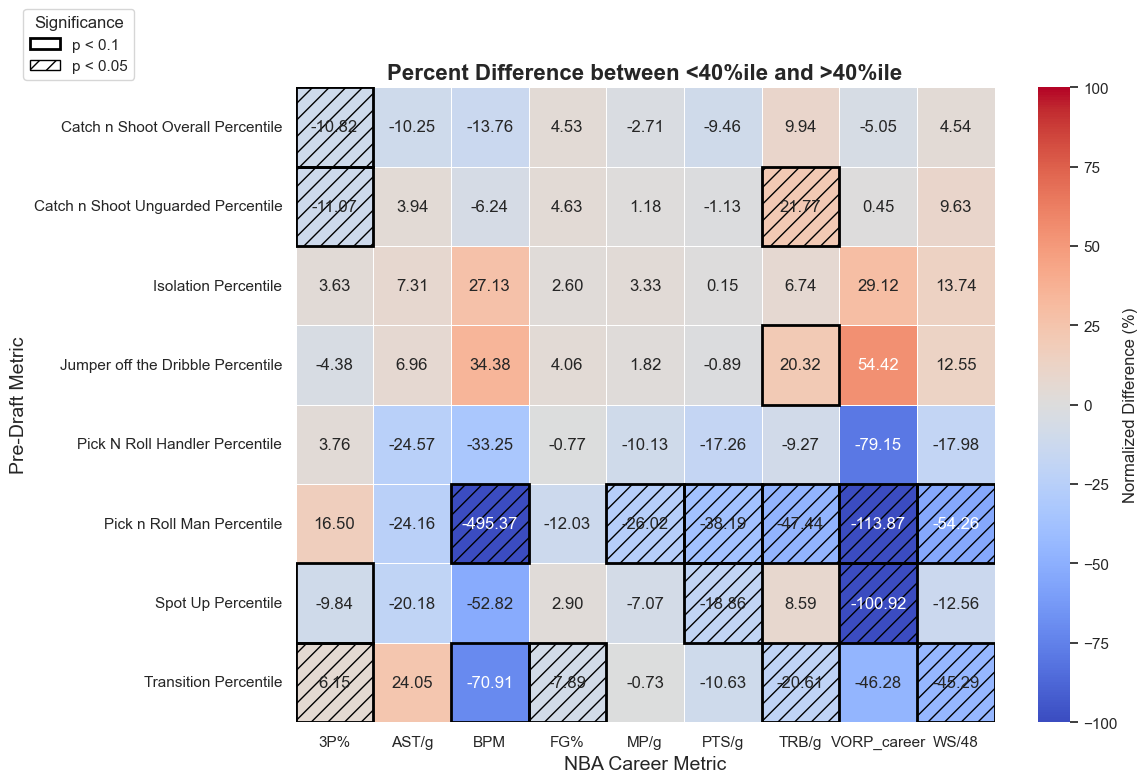

In [72]:
result_df = get_group_means_ttest_df(all_df)
pval_df = result_df.pivot(index='x_col', columns='y_col', values='p_value')
mean_diff_norm_df = result_df.pivot(index='x_col', columns='y_col', values='mean_diff_norm')
fig = plot_mean_diff_norm_heatmap(mean_diff_norm_df, pval_df, title="Percent Difference between <40%ile and >40%ile")
fig.savefig('./outputs/mean_diff_norm_heatmap.png', dpi=300, bbox_inches='tight')

### Interpretation

The heatmap above shows the difference in NBA career averages between groups of players whose Pre-Draft percentiles were above and below 40%. Blue indicates that the group below 40% had a lower value than the group above 40%, and red indicates a higher value.

The bolded boxes and hashing indicate levels of statistical significance, based on the p-value from a t-test. The p-value represents the probability of observing a difference at least as extreme as the one calculated, assuming that there is no true difference (null hypothesis).

A p-value less than 0.05 suggests that the observed difference is unlikely to have occurred by random chance, and we can say there is statistically significant evidence that the two groups differ. This means we have 95% confidence that the difference is not just due to random sampling variability. Thus, you can interpret the hatched and boxed segments of the heatmap as more statistically meaningful based on the available data.

<b>Example</b>: The average for players with Spot Up Percentile below 40% had a VORP score that was over 100% lower than those with percentiles above 40% in that category. It is boxed and hatched, indicating that the difference identified here is unlikely to be random. On the other hand, players with Jumper off the Dribble Percentile below 40% had a 54% higher VORP score than those with percentiles above 40% in that category, but the lack of boxing or hatching indicates less confidence in that result.

In [137]:
main_df = df_dict['First Round'].copy()
main_df.columns = main_df.columns.str.strip()  # Clean column names to ensure consistency
all_df = pd.merge(main_df, career_df, how='inner', left_on='PLAYER', right_on='Player', suffixes=('_draft', '_career'))

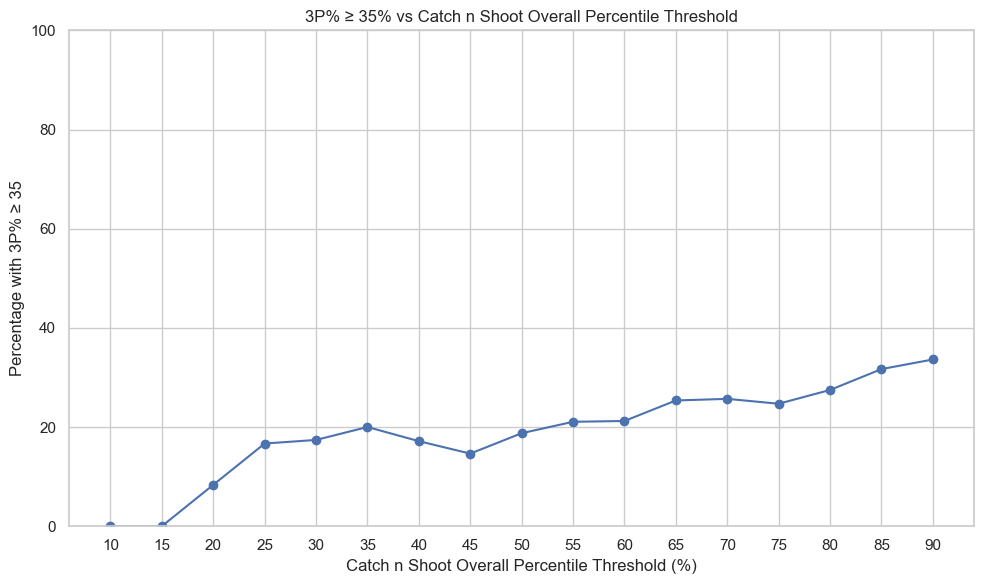

In [150]:
import pandas as pd
import matplotlib.pyplot as plt

tmp_df = all_df.copy()
x = 'Catch n Shoot Overall Percentile'
tmp_df[x] = pd.to_numeric(tmp_df[x], errors='coerce')
tmp_df['3P%'] = pd.to_numeric(tmp_df['3P%'], errors='coerce')

# Initialize results
thresholds = range(10, 91, 5)  # from 10% to 90% in steps of 5
percentages = []

for thresh in thresholds:
    threshold_value = thresh / 100
    subset = tmp_df[tmp_df[x] < threshold_value]
    if len(subset) > 0:
        pct_above_35 = len(subset[subset['3P%'] >= 0.35]) / len(subset) * 100
    else:
        pct_above_35 = float('nan')
    percentages.append(pct_above_35)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(thresholds, percentages, marker='o')
plt.title('3P% ≥ 35% vs Catch n Shoot Overall Percentile Threshold')
plt.xlabel('Catch n Shoot Overall Percentile Threshold (%)')
plt.ylabel('Percentage with 3P% ≥ 35')
plt.grid(True)
plt.xticks(thresholds)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


In [149]:
# Ensure columns are clean and numeric
tmp_df = all_df.copy()
x = 'Catch n Shoot Overall Percentile'
tmp_df[x] = pd.to_numeric(tmp_df[x], errors='coerce')
tmp_df['3P%'] = pd.to_numeric(tmp_df['3P%'], errors='coerce')

# Filter for players below 40 percentile
below_40 = tmp_df[tmp_df[x] < .4]

# Of those, how many have 3P% >= 33
above_33_pct = below_40[below_40['3P%'] >= 0.35]

# Calculate percentage
percentage = (len(above_33_pct) / len(below_40)) * 100 if len(below_40) > 0 else float('nan')

print(f"Percentage of players below 40 on {x} with ≥ 33% 3P: {percentage:.2f}%")
for index, row in above_33_pct.iterrows():
    print(f"{row['PLAYER']}: {row[x]} - {row['3P%']}")  # Print player name, percentile, and 3P%


Percentage of players below 40 on Catch n Shoot Overall Percentile with ≥ 33% 3P: 17.14%
Isaac Okoro: 0.18 - 0.351
Anthony Edwards: 0.32 - 0.364
Usman Garuba: 0.34 - 0.363
Tyrese Maxey: 0.2 - 0.381
Matas Buzelis: 0.24 - 0.361
MarJon Beauchamp: 0.26 - 0.354


In [147]:
# Ensure columns are clean and numeric
tmp_df = all_df.copy()
x = 'Spot Up Percentile'
tmp_df[x] = pd.to_numeric(tmp_df[x], errors='coerce')
tmp_df['3P%'] = pd.to_numeric(tmp_df['3P%'], errors='coerce')

# Filter for players below 40 percentile
below_40 = tmp_df[tmp_df[x] < .35]

# Of those, how many have 3P% >= 33
above_33_pct = below_40[below_40['3P%'] >= 0.35]

# Calculate percentage
percentage = (len(above_33_pct) / len(below_40)) * 100 if len(below_40) > 0 else float('nan')

print(f"Percentage of players below 40 on {x} with ≥ 33% 3P: {percentage:.2f}%")
for index, row in above_33_pct.iterrows():
    print(f"{row['PLAYER']}: {row[x]} - {row['3P%']}")  # Print player name, percentile, and 3P%

Percentage of players below 40 on Spot Up Percentile with ≥ 33% 3P: 13.04%
Patrick Williams: 0.32 - 0.392
Matas Buzelis: 0.29 - 0.361
MarJon Beauchamp: 0.28 - 0.354


In [145]:
# Ensure columns are clean and numeric
tmp_df = all_df.copy()
x = 'Catch n Shoot Unguarded Percentile'
tmp_df[x] = pd.to_numeric(tmp_df[x], errors='coerce')
tmp_df['3P%'] = pd.to_numeric(tmp_df['3P%'], errors='coerce')

# Filter for players below 40 percentile
below_40 = tmp_df[tmp_df[x] < .4]

# Of those, how many have 3P% >= 33
above_33_pct = below_40[below_40['3P%'] >= 0.35]

# Calculate percentage
percentage = (len(above_33_pct) / len(below_40)) * 100 if len(below_40) > 0 else float('nan')

print(f"Percentage of players below 40 on {x} with ≥ 33% 3P: {percentage:.2f}%")
for index, row in above_33_pct.iterrows():
    print(f"{row['PLAYER']}: {row[x]} - {row['3P%']}")  # Print player name, percentile, and 3P%

Percentage of players below 40 on Catch n Shoot Unguarded Percentile with ≥ 33% 3P: 18.75%
Grant Williams: 0.32 - 0.377
Isaac Okoro: 0.36 - 0.351
Kevin Porter Jr.: 0.36 - 0.351
Anthony Edwards: 0.22 - 0.364
Chet Holmgren: 0.39 - 0.372
Matas Buzelis: 0.07 - 0.361


In [144]:
# Ensure columns are clean and numeric
tmp_df = all_df.copy()
x = 'Jumper off the Dribble Percentile'
tmp_df[x] = pd.to_numeric(tmp_df[x], errors='coerce')
tmp_df['3P%'] = pd.to_numeric(tmp_df['3P%'], errors='coerce')

# Filter for players below 40 percentile
below_40 = tmp_df[tmp_df[x] < .4]

# Of those, how many have 3P% >= 33
above_33_pct = below_40[below_40['3P%'] >= 0.35]

# Calculate percentage
percentage = (len(above_33_pct) / len(below_40)) * 100 if len(below_40) > 0 else float('nan')

print(f"Percentage of players below 40 on {x} with ≥ 33% 3P: {percentage:.2f}%")
for index, row in above_33_pct.iterrows():
    print(f"{row['PLAYER']}: {row[x]} - {row['3P%']}")  # Print player name, percentile, and 3P%

Percentage of players below 40 on Jumper off the Dribble Percentile with ≥ 33% 3P: 27.27%
Tyrese Haliburton: 0.35 - 0.392
Saddiq Bey: 0.39 - 0.352
Coby White: 0.27 - 0.369
Ochai Agbaji: 0.31 - 0.353
Josh Green: 0.09 - 0.38
Jake LaRavia: 0.27 - 0.371
LaMelo Ball: 0.29 - 0.365
Jarace Walker: 0.29 - 0.404
Matas Buzelis: 0.3 - 0.361


In [156]:
pd.to_numeric(tmp_df[x], errors='coerce')

TypeError: arg must be a list, tuple, 1-d array, or Series

In [159]:
tmp_df[(tmp_df[x[0]] < 0.4) & (tmp_df[x[1]] < 0.4)]

,first,Pick,PLAYER,SCHOOL,YEAR,POS,Age,HT,WT,G_draft,...,FT%,MP/g,PTS/g,TRB/g,AST/g,WS,WS/48,BPM,VORP_career,Player ID_career
119,2022,8,Dyson Daniels,Centre of Excellence,2003,SG/SF,NaN,2025-06-07 00:00:00,195,196,...,0.614,25.4,8.4,4.5,3.2,9.2,0.089,0.5,3.2,1630700
124,2024,28,Ryan Dunn,21.5,Virginia,So.,Forward,"6'7 ½""",216,32,...,0.487,19.1,6.9,3.6,0.8,1,0.034,-4.1,-0.7,1642346
126,2024,14,Bub Carrington,18.9,Pitt,Fr.,Lead Guard,"6'5""",190,82,...,0.812,30,9.8,4.2,4.4,0.2,0.005,-4.6,-1.6,1642267
127,2024,5,Ron Holland,19,Ignite,2005,Wing,"6'7 ¼""",206,81,...,0.754,15.6,6.4,2.7,1,1.8,0.067,-3,-0.3,204066
128,2024,11,Matas Buzelis,19.7,Ignite,2004,Wing,"6'10 ½""",208,80,...,0.815,18.9,8.6,3.5,1,1.9,0.06,-2.5,-0.2,1641824
129,2020,16,Isaiah Stewart,Washington,Freshman,C,19,6'9,250,307,...,0.733,24.6,8.6,7.1,1.3,15.4,0.098,-1.7,0.5,1630191
130,2024,4,Stephon Castle,19.7,UConn,Fr.,Combo Guard,"6'6""",208,81,...,0.724,26.7,14.7,3.7,4.1,1.1,0.025,-3.2,-0.6,1642264
132,2022,11,Ousmane Dieng,CFBB,2003,SG/SF,NaN,2025-06-09 00:00:00,185,109,...,0.727,12.3,4.3,2.2,1,1.7,0.062,-2.6,-0.2,1631172
134,2022,22,Walker Kessler,Auburn,So.,C,NaN,2025-07-01 00:00:00,255,196,...,0.537,25.2,9.4,9.2,1.2,16.6,0.161,1.9,4.9,1631117
135,2023,17,Jalen Hood-Schifino,Indiana,Fr,PG,NaN,2025-06-06 00:00:00,213,36,...,0.732,11.8,3.9,1.1,1.3,-0.6,-0.068,-9.3,-0.8,1641720


In [162]:
# Ensure columns are clean and numeric
tmp_df = all_df.copy()
x = ['Catch n Shoot Unguarded Percentile', 'Jumper off the Dribble Percentile']
for col in x:
    if col in tmp_df.columns:
        tmp_df[col] = pd.to_numeric(tmp_df[col], errors='coerce')
tmp_df['3P%'] = pd.to_numeric(tmp_df['3P%'], errors='coerce')

# Filter for players below 40 percentile
# Get rows where all specified x columns are below 0.4
below_40 = tmp_df[(tmp_df[x[0]] < 0.4) & (tmp_df[x[1]] < 0.4)]

# Of those, how many have 3P% >= 33
above_33_pct = below_40[below_40['3P%'] >= 0.33]

# Calculate percentage
percentage = (len(above_33_pct) / len(below_40)) * 100 if len(below_40) > 0 else float('nan')

print(f"Percentage of players below 40 on {x} with ≥ 33% 3P: {percentage:.2f}%")
for index, row in above_33_pct.iterrows():
    print(f"{row['PLAYER']}: {row[x]} - {row['3P%']}")  # Print player name, percentile, and 3P%

Percentage of players below 40 on ['Catch n Shoot Unguarded Percentile', 'Jumper off the Dribble Percentile'] with ≥ 33% 3P: 40.00%
Scoot Henderson: Catch n Shoot Unguarded Percentile    0.19
Jumper off the Dribble Percentile     0.38
Name: 72, dtype: object - 0.34
Matas Buzelis: Catch n Shoot Unguarded Percentile    0.07
Jumper off the Dribble Percentile      0.3
Name: 128, dtype: object - 0.361
Isaiah Stewart: Catch n Shoot Unguarded Percentile    0.07
Jumper off the Dribble Percentile      0.0
Name: 129, dtype: object - 0.345
Jonathan Kuminga: Catch n Shoot Unguarded Percentile    0.18
Jumper off the Dribble Percentile     0.16
Name: 137, dtype: object - 0.332


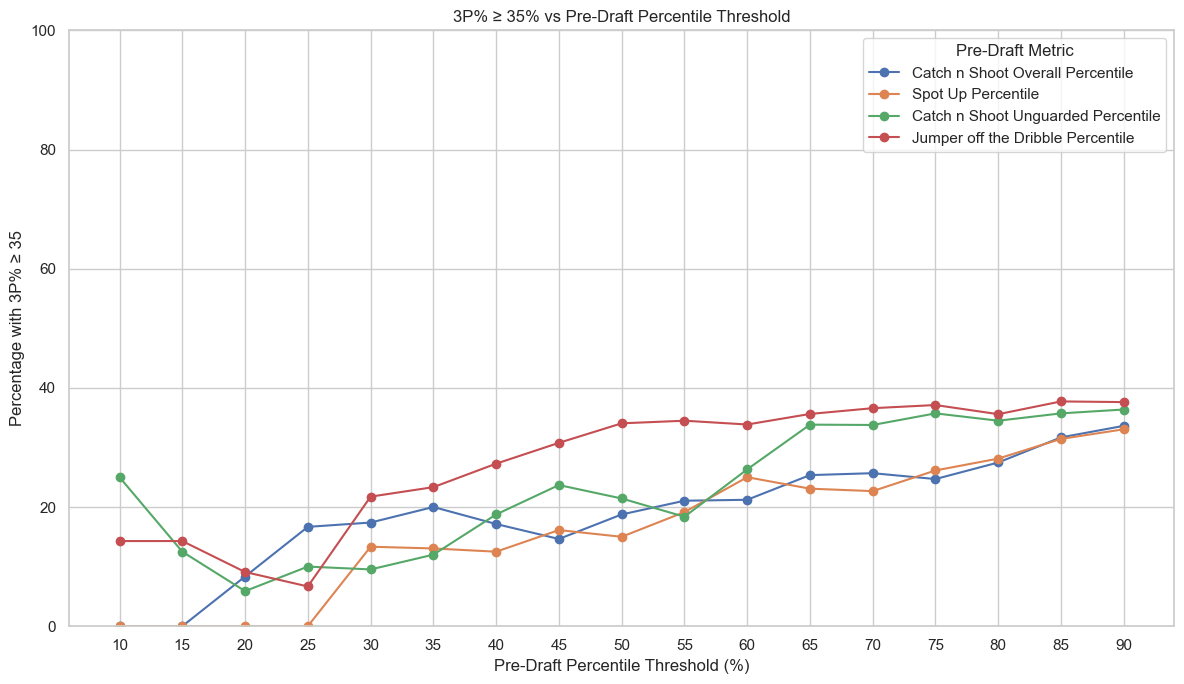

In [153]:
import pandas as pd
import matplotlib.pyplot as plt

x_vars = [
    'Catch n Shoot Overall Percentile',
    'Spot Up Percentile',
    'Catch n Shoot Unguarded Percentile',
    'Jumper off the Dribble Percentile'
]

thresholds = range(10, 91, 5)
three_point_threshold = 0.35

fig = plt.figure(figsize=(12, 7))

for x in x_vars:
    tmp_df = all_df.copy()
    tmp_df[x] = pd.to_numeric(tmp_df[x], errors='coerce')
    tmp_df['3P%'] = pd.to_numeric(tmp_df['3P%'], errors='coerce')

    percentages = []
    for thresh in thresholds:
        threshold_value = thresh / 100
        subset = tmp_df[tmp_df[x] < threshold_value]
        if len(subset) > 0:
            pct_above = len(subset[subset['3P%'] >= three_point_threshold]) / len(subset) * 100
        else:
            pct_above = float('nan')
        percentages.append(pct_above)

    plt.plot(thresholds, percentages, marker='o', label=x)

# Final plot formatting
plt.title(f'3P% ≥ {three_point_threshold*100:.0f}% vs Pre-Draft Percentile Threshold')
plt.xlabel('Pre-Draft Percentile Threshold (%)')
plt.ylabel(f'Percentage with 3P% ≥ {three_point_threshold*100:.0f}')
plt.grid(True)
plt.xticks(thresholds)
plt.ylim(0, 100)
plt.legend(title='Pre-Draft Metric')
plt.tight_layout()
plt.show()

fig.savefig('./outputs/3P_percentile_thresholds.png', dpi=300, bbox_inches='tight')


In [ ]:
all_df.Player_id

In [173]:
main_df = df_dict['First Round'].copy()
main_df.columns = main_df.columns.str.strip()  # Clean column names to ensure consistency
all_df = pd.merge(main_df, career_df, how='left', left_on='PLAYER', right_on='Player', suffixes=('_draft', '_career'))
new_columns = all_df.columns.tolist()
for i, col in enumerate(new_columns):
    if 'Makes and Attempts' in col:
        # Replace 'Makes and Attempts' with 'Makes' and 'Attempts'
        new_columns[i] = col.replace('Makes and Attempts', 'Makes')
    if "Unnamed" in col and i > 0:
        prev_col = new_columns[i - 1]
        if "Makes" in prev_col:
            base = prev_col.replace("Makes", "").strip().rstrip(':')
            new_columns[i] = f"{base} Attempts"
        elif "EFF" in prev_col:  # Optional: handle efficiency or other metrics
            new_columns[i] = f"{prev_col} Attempts"

# Apply the cleaned names
all_df.columns = new_columns

# drop columns
columns_to_drop = ['Player ID_draft', 'Player ID_career', 'Player','College','Rk','Pk']
all_df.drop(columns=columns_to_drop, inplace=True, errors='ignore')
all_df.replace('nan',None, inplace=True)  # Replace 'nan' strings with actual NaN values
all_df.replace('na', None, inplace=True)  # Replace 'na' strings with actual NaN values

# numeric cols
non_numeric_cols = ['PLAYER','SCHOOL','YEAR','POS','Age','HT','Tm','']
for col in all_df.columns:
    if col not in non_numeric_cols:
        all_df[col] = pd.to_numeric(all_df[col], errors='coerce')

all_df

,first,Pick,PLAYER,SCHOOL,YEAR,POS,Age,HT,WT,G_draft,...,3P%,FT%,MP/g,PTS/g,TRB/g,AST/g,WS,WS/48,BPM,VORP_career
0,2019,8,Jaxson Hayes,Texas,Fr,C,1,6'11,220.0,367.0,...,0.261,0.696,16.4,6.8,3.9,0.7,20.1,0.160,-0.4,2.5
1,2024,3,Reed Sheppard,20,Kentucky,Fr.,Combo Guard,"6'2""",187.0,52.0,...,0.338,0.813,12.6,4.4,1.5,1.4,0.8,0.055,-1.7,0.1
2,2019,8,Bol Bol,Oregon,Fr,C,2,43653,208.0,337.0,...,0.332,0.749,13.6,6.2,3.5,0.6,5.0,0.088,-0.4,1.1
3,2020,12,Tyrese Haliburton,Iowa State,Sophmore,G,20,6'5,175.0,333.0,...,0.392,0.855,33.0,17.5,3.7,8.8,37.6,0.164,4.8,18.9
4,2020,19,Saddiq Bey,Villanova,Sophmore,F,21,6'8,215.0,292.0,...,0.352,0.842,30.2,14.1,5.2,1.8,14.6,0.079,-0.7,2.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174,2023,30,Kobe Brown,Missouri,NaN,NaN,NaN,NaN,NaN,NaN,...,0.270,0.667,7.9,2.0,1.5,0.6,0.9,0.067,-3.1,-0.2
175,2023,21,Noah Cloney,NaN,NaN,NaN,NaN,NaN,NaN,69.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
176,2024,7,Donovan Clingan,20.3,UConn,So.,Big,"7'2""",280.0,67.0,...,0.286,0.596,19.8,6.5,7.9,1.1,4.0,0.144,-0.3,0.6
177,2024,9,Zach Edey,22.3,Purdue,Sr.,Big,"7'4""",306.0,66.0,...,0.346,0.709,21.5,9.2,8.3,1.0,4.9,0.165,-0.1,0.7


In [174]:
all_df.to_excel('./outputs/nba_pre_draft_career_data.xlsx', index=False)